<img src="./imagenes/logo_UTN.svg" align="right" width="200"/>

# **Teoría de Circuitos II**
## Trabajo Semanal 1

---
**Profesor:** Mariano Llamedo Soria \
**Ayudante de TPs:** David Moharos \
**Jefe de TPs:** César Fuoco

**Alumno:** Valentin Dorrego\
**Curso:** R4052\
**Ciclo lectivo:** 2026  

---

### Dado el siguiente circuito:

<div align="center">
  <img src="imagenes/1/Circuito-TrabajoSemanal1.png" width="700">
</div>


Se pide lo siguiente:

1. Obtener analíticamente la función transferencia  
   $T(s) = \frac{V_2(s)}{V_1(s)}$.  
   Realizar diagramas de módulo, fase y de polos y ceros para el caso en el que el ratio $\frac{R_2}{R_1}$ sea unitario.

2. ¿De qué tipo de filtro se trata? Investigue y comente brevemente qué utilidad podría tener este tipo de circuitos.

3. Proponga una norma de impedancia $\Omega_z$ y frecuencia $\Omega_\omega$ de forma tal de llegar a una transferencia **normalizada** (escalada en impedancia y frecuencia).

4. Simule numéricamente la **función transferencia normalizada** en Python.

5. Obtener una **red normalizada** que responda a la función hallada en el inciso anterior.

6. Simule la **red normalizada** en LTspice y obtenga su respuesta en frecuencia.

---

### Bonus:

- Verifique los resultados de los incisos 1 y 3 mediante el módulo de simulación simbólica **SymPy**.
- Analice similitudes y diferencias entre la presente red y la del ejercicio 07 del apartado **"Amplificadores OPAMP y OTA"** de la guía de TPs.
- Presentación en Jupyter Notebook.
---

### Resolucion

1.
   Partimos considerando el opamp ideal y correctamente realimentado. Sabemos que nuestros dos nodos de interes son el que une las resistencias $R_1$ y $R_2$ con la entrada diferencial negativa denominado nodo $V_a$ y el que une el capacitor $C_1$ y la resistencia $R_3$ con la entrada diferencial positiva denominado nodo $V_b$. 
   
   Como el amplificador operacional es ideal y está correctamente realimentado en forma negativa, se cumple la condición de cortocircuito virtual entre sus entradas, es decir:$V_a = V_b$. Además, debido a la alta impedancia de entrada del opamp, no circula corriente hacia ninguna de sus entradas.

   Considerando esto, podemos sacar las primeras ecuaciones aplicando nodos.
$$
\begin{aligned}
1)\quad V_a \cdot (G_1 + G_2) - V_2 \cdot G_2 - V_1 \cdot G_1 = 0 \\
2)\quad V_a \cdot (G_3 + sC_1) - V_1 \cdot (sC_1) = 0
\end{aligned}
$$
   Despejando $V_a$ de la ecuacion $2$ y reemplazando en la ecuacion $1$ obtenemos la transferencia $T(s) = V_2(s)/V_1(s)$.
$$
\begin{aligned}
\quad T(s) = \frac{s-\frac{G_1 \cdot G_3}{G_2 \cdot C_1}}{s+\frac{G_3}{C_1}}
\end{aligned}
$$
   Particularmente el ejercicio nos pide que evaluemos en el caso en donde el ratio $\frac{R_2}{R_1}=1$, por lo tanto la transferencia nos queda:
$$
\begin{aligned}
\quad T(s) = \frac{s-\frac{G_3}{C_1}}{s+\frac{G_3}{C_1}}
\end{aligned}
$$

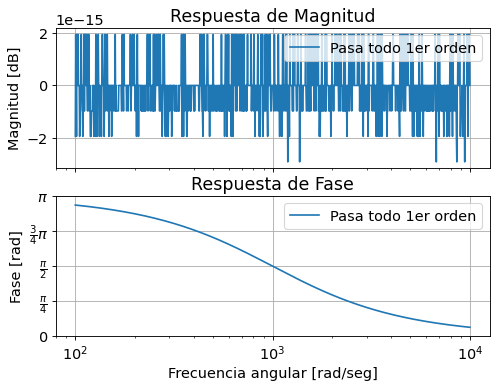

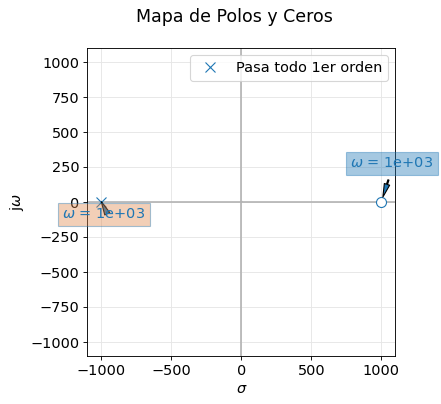

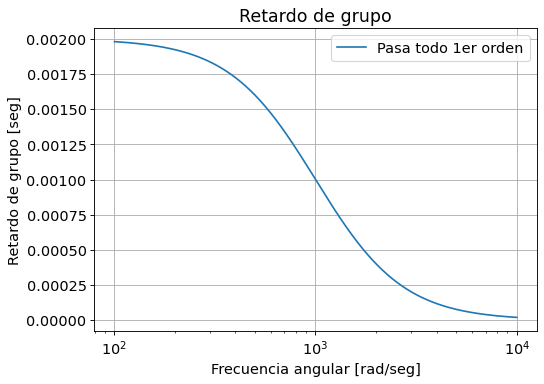

In [1]:
# Inicialización e importación de módulos
%matplotlib inline
# Módulos externos
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig
from pytc2.sistemas_lineales import analyze_sys
from IPython.display import display, HTML


# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
display(HTML("<style>.output_png { display: table; margin-left: auto; margin-right: auto; }</style>"))
fig_sz_x = 7
fig_sz_y = 5
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

#!/usr/bin/env python3
# -*- coding: utf-8 -*-

#%% parámetros
G3 = 1e-3
C1 = 1e-6

a = G3 / C1

#%% función de transferencia T(s) = (s - a)/(s + a)
num = np.array([1, -a])   # s - a
den = np.array([1,  a])   # s + a

T_s = sig.TransferFunction(num, den)

#%% análisis
plt.close('all')
analyze_sys(T_s, 'Pasa todo 1er orden')
plt.tight_layout()
plt.show()

**Nota:** El modulo se ve esa manera debido a la escala del grafico, pero en realidad es una linea cte. Se tomó $R_3 = 1k \ohm$ y $C_1=1\micro F$.

2. Si evaluamos el modulo y la fase:
$$
\begin{gathered}
|T(s)| = \frac{\sqrt{s^2+\left(-\frac{G_3}{C_1}\right)^2}}{\sqrt{s^2+\left(\frac{G_3}{C_1}\right)^2}} = 1 \\
\angle T = \angle\left(s-\frac{G_3}{C_1}\right) - \angle\left(s+\frac{G_3}{C_1}\right) = \pi - 2 \cdot \tan^{-1}\left( \frac{\omega C_1}{G_3}\right)
\end{gathered}
$$
  Como podemos notar, estamos frente a un **filtro pasatodo** debido a que el modulo de la transferencia es 1, o sea que no cambia la amplitud de la entrada, en lo unico que afecta es en la fase, en donde si
  $\omega \rightarrow 0:$  $$\angle T \rightarrow \pi$$ y si $\omega \rightarrow \infty:$  $$\angle T \rightarrow 0$$
   Sirven para realizar correcciones de **fase** y controlar el **retardo de grupo**, reduciendo la distorcion temporal. Generalmente son utilizados en audio y sistemas de comunicaciones.

3. El objetivo es llegar a una transferencia **normalizada mixta**, por lo tanto partimos por la normalizacion de impedancia.
   Para relizar la **normalizacion de impedancia** tomo una norma de impedancia $\Omega_z = R_3$ por lo tanto nos queda $G_3'=G_3 \cdot \Omega_z$ y $ C_1'=C_1 \cdot \Omega_z$.
$$
\begin{aligned}
\quad T(s) = \frac{s-\frac{G_3'}{C_1'}}{s+\frac{G_3'}{C_1'}}=\frac{s-\frac{G_3}{C_1}}{s+\frac{G_3}{C_1}}
\end{aligned}
$$
Para **normalizar en frecuencia** tomo una norma de frecuencia $\Omega_w=\omega_0=G_3/C_1$ para que al reemplazar $\cancel{s} \cdot \omega_0=s$ la transferencia nos quede finalmente de la siguiente forma:
$$
\boxed{
\begin{aligned}
T(\cancel{s}) = \frac{\cancel{s} \cdot \omega_0-\omega_0}{\cancel{s} \cdot \omega_0+\omega_0}
= \frac{\cancel{s}-1}{\cancel{s}+1}
\end{aligned}
}
$$
 

4. Realizamos el script para la simulacion numerica de la funcion **transferencia normalizada**, o sea del sistema escalado, por lo tanto del script anterior en donde teniamos $\omega_0=1000\frac{rad}{s}$ ahora tenemos $\omega_0=1\frac{rad}{s}$

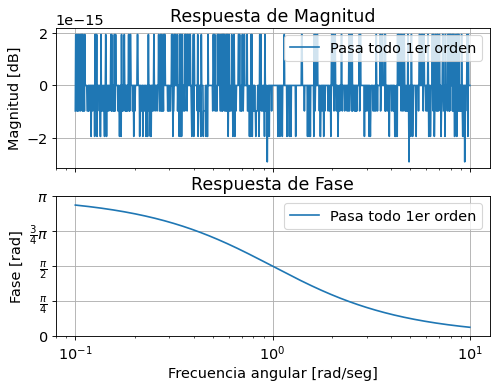

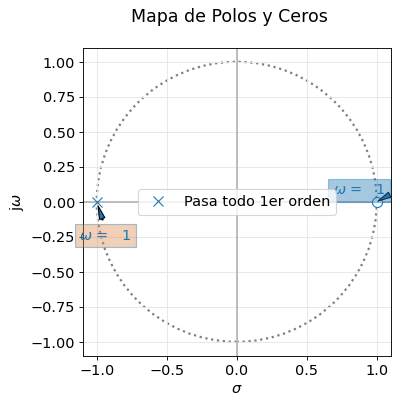

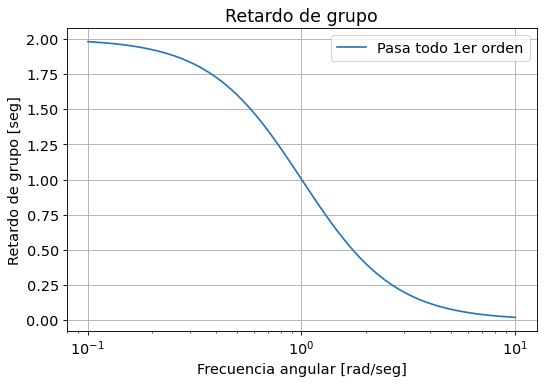

In [4]:
# Inicialización e importación de módulos
%matplotlib inline
# Módulos externos
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig
from pytc2.sistemas_lineales import analyze_sys
from IPython.display import display, HTML


# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
display(HTML("<style>.output_png { display: table; margin-left: auto; margin-right: auto; }</style>"))
fig_sz_x = 7
fig_sz_y = 5
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

#!/usr/bin/env python3
# -*- coding: utf-8 -*-

#%% parámetros
#G3 = 1e-3
#C1 = 1e-6

#a = G3 / C1

#%% función de transferencia T(s) = (s - 1)/(s + 1)
num_n = np.array([1, -1])   # s' - 1
den_n = np.array([1,  1])   # s' + 1

T_s = sig.TransferFunction(num_n, den_n)

#%% análisis
plt.close('all')
analyze_sys(T_s, 'Pasa todo 1er orden')
plt.tight_layout()
plt.show()

5. Para obtener una red normalizada que responda a la transferencia del inciso anterior, había considerado $G_3/C_1=1$ entonces tomando $R_3=100k\ohm$ y $C_1=10\micro F$. Cambian los valores de $R_3$ y $C_1$ pero $\omega_0$ sigue estando en $1 \frac{rad}{s}$m, esto es de mucha utilidad al momento de adaptar la frecuencia caracteristica o componentes que querramos. Como $R_1$ y $R_2$ no afectan a la transferencia, sus valores seran de poco interés.
<div align="center">
  <img src="imagenes/1/CircuitoPunto5.png" width="400">
</div>


6: Simulacion del inciso anterior:
<div align="center">
  <img src="imagenes/1/TransferenciaPunto6.png" width="600">
</div>
Hay que considerar que python grafica en $\frac{rad}{s}$ y que el LTSpice grafica en $Hz$ entonces la frecuencia caracteristiac es en $f_0\approx0.16Hz$ lo cual coincide con el script anterior.


---
### Anexo Calculos:
[Ver PDF](https://github.com/ValentinDorrego/tc2/blob/main/jupyterNotebooks/Pdfs/TrabajoSemanal1Res.pdf)


In [3]:
from IPython.display import display, HTML

display(HTML("""
<div style="display: flex; justify-content: center;">
    <iframe src="./Pdfs/TrabajoSemanal1Res.pdf" width="900" height="900"></iframe>
</div>
"""))

---